In [1]:
print()

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [16]:
# define agentstate - shared datastructure for the graph that keeps information presistent across nodes.
class AgentState(TypedDict):    # our state schema
    message: str

# define a node - just another python function that takes the state as input and returns the state as output. The state is passed to the next node in the graph.
def greet_node(state: AgentState) -> AgentState:
    """A simple node that adds a greeting message to the state."""
    state["message"] = "Hello " + state["message"] + ", My Friend!"
    return state

In [17]:
# lets build the actual graph now - in langgraph

graph = StateGraph(AgentState)  # pass the state schema to the graph so that it knows what kind of state to expect and return

graph.add_node(greet_node, name="greet_node")   # 2 parameters used: action to be performed by node (node function) , name of node (can be anything sensible)
graph.set_entry_point("greet_node")  # set the starting node of the graph | start node connects to greet_node
graph.set_finish_point("greet_node")    # set the ending node of the graph | greet node connects to end node

app = graph.compile()  # compile the graph - this will check for any errors in the graph and prepare it for execution

IPython lib to visulize the graph

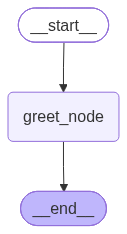

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

In [18]:
result = app.invoke({"message": "bob"})  # invoke the graph with the initial state | this will start the execution of the graph from the entry point and pass the state to the first node

here we access the only attribute in our state of the graph

In [19]:
result['message']  # print the final state after the graph execution

'Hello bob, My Friend!'